# Week 3 — Day 5: End-to-End Mini-Project

**Program:** BinX Tech AI & ML Internship — Phase 2, Week 3
**Topic:** The full supervised-learning pipeline: EDA -> preprocessing -> train/test split -> modeling -> evaluation
**Dataset:** Breast Cancer Wisconsin dataset (built into scikit-learn), with a synthetic categorical feature and a
few missing values deliberately introduced so the preprocessing stage is genuinely exercised.


## 1. The Full Supervised-Learning Pipeline

Every real ML project follows this same shape — it's the exact structure the Phase 3 capstone will formalize:

| Stage | What Happens |
|---|---|
| 1. EDA | Understand the data (Week 2 methodology): distributions, correlations, problems |
| 2. Preprocessing | Handle missing values, encode categoricals, scale features |
| 3. Train/test split | Hold out unseen data for honest evaluation |
| 4. Modeling | Train one or more models via the scikit-learn API |
| 5. Evaluation | Measure performance with the right metric vs. a baseline |


## 2. Basic Preprocessing

Two preprocessing steps appear in almost every project:

- **One-hot encoding** — models only accept numbers, so text categories must be converted to numeric columns.
- **Feature scaling** — puts all numeric features on a comparable range, which matters greatly for distance- and margin-based models like k-NN and SVM.

```python
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # transform only, never fit on test
```

**Critical rule:** fit the scaler on the training data only, then apply it to the test data. Fitting on the full dataset leaks information from the test set into training and inflates results — a subtle but serious mistake known as **data leakage**.


## 3. Choosing the Right Model and Metric

The mini-project requires two real decisions:
1. Is this task regression or classification? That determines which models and metrics even apply.
2. Which metric best reflects success for *this specific* problem?

Making and justifying these choices — not just running code — is what separates real analysis from copy-pasted code.


## 4. Documenting the Result

The deliverable is a clean, narrated notebook: each stage explained in Markdown, each choice justified, and the final result compared honestly against a baseline. A model is only meaningful relative to what it beats.


---

## Hands-On Lab: End-to-End Mini-Project

**Goal:** take a dataset all the way from raw data to an evaluated, justified model choice.

**Steps:**
1. Load the dataset and determine whether the task is regression or classification.
2. Perform brief EDA: check shape, missing values, class balance, and a quick correlation look.
3. Preprocess: handle missing values, one-hot encode the categorical feature, and scale numeric features (fit on train only).
4. Split into train/test, then train at least two models and evaluate them with a suitable metric against a baseline.
5. Select the better model, justify the choice, and document the full pipeline.


### Step 1: Load the dataset and determine the task type

We're using the Breast Cancer Wisconsin dataset. The target is binary (malignant vs. benign), so this is a
**classification** task. To make preprocessing meaningful, we add a synthetic categorical feature
(`clinic_region`) and introduce a handful of missing values into one numeric column — the kind of messiness
a real dataset would actually have.


In [ ]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer

np.random.seed(42)

cancer = load_breast_cancer(as_frame=True)
df = cancer.frame.copy()

# --- Make the dataset a bit more realistic for this pipeline exercise ---

# Add a synthetic categorical feature (not part of the original dataset)
df["clinic_region"] = np.random.choice(["North", "South", "East", "West"], size=len(df))

# Deliberately introduce missing values into one numeric column
missing_idx = np.random.choice(df.index, size=15, replace=False)
df.loc[missing_idx, "mean radius"] = np.nan

print("Shape:", df.shape)
print("\nTask type: CLASSIFICATION (target is 0 = malignant, 1 = benign)")
df.head()


Shape: (569, 32)

Task type: CLASSIFICATION (target is 0 = malignant, 1 = benign)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,clinic_region
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,East
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,West
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,North
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,East
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,East


### Step 2: Brief EDA

In [ ]:
# Missing values
print("Missing values per column (only showing columns with any):")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Class balance
print("\nClass balance:")
print(df["target"].value_counts(normalize=True).rename({0: "malignant", 1: "benign"}))


Missing values per column (only showing columns with any):
mean radius    15
dtype: int64

Class balance:
target
benign       0.627417
malignant    0.372583
Name: proportion, dtype: float64


/tmp/ipykernel_490/1338868643.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["Malignant", "Benign"])


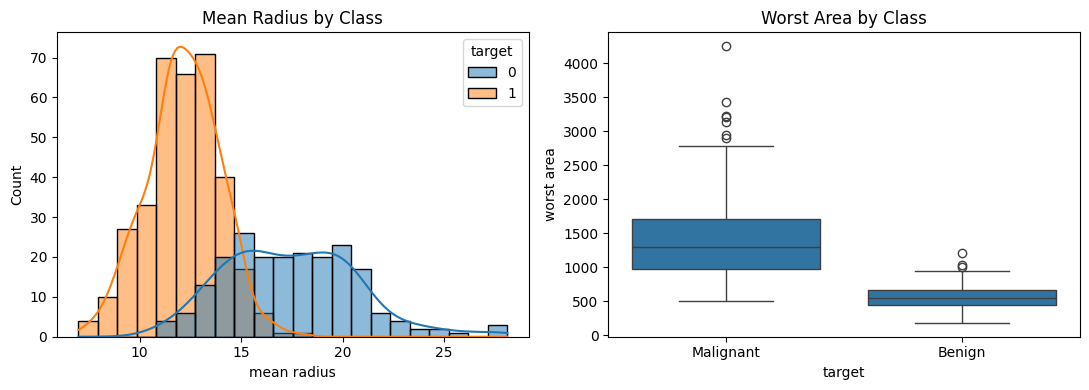

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.histplot(data=df, x="mean radius", hue="target", kde=True, ax=axes[0])
axes[0].set_title("Mean Radius by Class")

sns.boxplot(data=df, x="target", y="worst area", ax=axes[1])
axes[1].set_xticklabels(["Malignant", "Benign"])
axes[1].set_title("Worst Area by Class")

plt.tight_layout()
plt.show()


### Step 2 (continued): What does the EDA show?

The classes are imbalanced but not severely — roughly 63% benign and 37% malignant (357 vs. 212 samples). That's moderate imbalance, not the extreme 95/5 kind, but it's still enough that accuracy alone shouldn't be fully trusted — a model could inflate its score somewhat just by leaning toward the majority class. Precision, recall, and F1 are the safer metrics to judge this on, which is exactly why the model comparison in Step 4 tracks all of them.

Both plots suggest mean radius and worst area will be strong predictors. The histogram shows the two classes' mean radius distributions are visibly separated, with malignant tumors clustering at higher radius values than benign ones — some overlap exists, but the separation is clear. The box plot tells the same story even more sharply for worst area: malignant cases have a noticeably higher median and a wider spread than benign cases, with very little overlap between the two boxes. Together, this confirms what Day 4's feature importances already found — size-related measurements are among the most informative features in this dataset.

### Step 3: Preprocess — missing values, encoding, and scaling

In [ ]:
from sklearn.model_selection import train_test_split

# Separate features and target BEFORE any preprocessing
X = df.drop("target", axis=1)
y = df["target"]

# Split first -- preprocessing must be fit on the training data only
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)


X_train shape: (455, 31)
X_test shape:  (114, 31)


In [ ]:
# --- Handle missing values (fit imputation strategy on train only) ---
from sklearn.impute import SimpleImputer

numeric_cols = X_train.select_dtypes(include=np.number).columns
categorical_cols = X_train.select_dtypes(exclude=np.number).columns

imputer = SimpleImputer(strategy="median")
X_train[numeric_cols] = imputer.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = imputer.transform(X_test[numeric_cols])  # transform only

print("Remaining missing values in X_train:", X_train.isnull().sum().sum())
print("Remaining missing values in X_test: ", X_test.isnull().sum().sum())


Remaining missing values in X_train: 0
Remaining missing values in X_test:  0


In [6]:
# --- One-hot encode the categorical feature ---
X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

# Align test columns to train columns (in case a category is missing from one split)
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

print("X_train_encoded shape:", X_train_encoded.shape)
print("X_test_encoded shape: ", X_test_encoded.shape)
X_train_encoded.head()


X_train_encoded shape: (455, 33)
X_test_encoded shape:  (114, 33)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,clinic_region_North,clinic_region_South,clinic_region_West
546,10.32,16.35,65.31,324.9,0.09434,0.04994,0.01012,0.005495,0.1885,0.06201,...,384.9,0.1285,0.08842,0.04384,0.02381,0.2681,0.07399,True,False,False
432,20.18,19.54,133.80,1250.0,0.11330,0.14890,0.21330,0.125900,0.1724,0.06053,...,1479.0,0.1665,0.29420,0.53080,0.21730,0.3032,0.08075,True,False,False
174,10.66,15.15,67.49,349.6,0.08792,0.04302,0.00000,0.000000,0.1928,0.05975,...,408.3,0.1076,0.06791,0.00000,0.00000,0.2710,0.06164,False,False,True
221,13.56,13.90,88.59,561.3,0.10510,0.11920,0.07860,0.044510,0.1962,0.06303,...,686.6,0.1376,0.26980,0.25770,0.09090,0.3065,0.08177,False,False,False
289,11.37,18.89,72.17,396.0,0.08713,0.05008,0.02399,0.021730,0.2013,0.05955,...,459.3,0.1118,0.09708,0.07529,0.06203,0.3267,0.06994,False,False,True


In [ ]:
# --- Scale numeric features (fit on train only, never on test) ---
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)  # transform only -- no leakage

print("Scaling complete. X_train_scaled shape:", X_train_scaled.shape)


Scaling complete. X_train_scaled shape: (455, 33)


### Step 4: Train at least two models and evaluate against a baseline

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, roc_auc_score

# Baseline: always predicts the most frequent class
baseline = DummyClassifier(strategy="most_frequent", random_state=42)
baseline.fit(X_train_scaled, y_train)

candidates = {
    "Baseline (most frequent)": baseline,
    "Logistic Regression": LogisticRegression(max_iter=5000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
}

results = []
for name, model in candidates.items():
    if name != "Baseline (most frequent)":
        model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    probs = model.predict_proba(X_test_scaled)[:, 1]
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds, zero_division=0),
        "Recall": recall_score(y_test, preds, zero_division=0),
        "F1-score": f1_score(y_test, preds, zero_division=0),
        "AUC-ROC": roc_auc_score(y_test, probs),
    })

results_df = pd.DataFrame(results).sort_values("F1-score", ascending=False).reset_index(drop=True)
results_df


,Model,Accuracy,Precision,Recall,F1-score,AUC-ROC
0,Logistic Regression,0.964912,0.985714,0.958333,0.971831,0.993056
1,Random Forest,0.956140,0.958904,0.972222,0.965517,0.994709
2,Baseline (most frequent),0.631579,0.631579,1.000000,0.774194,0.500000


### Step 5: Select the better model and justify the choice

Both models crushed the baseline (F1 ≈ 0.77 → ≈ 0.97). Since a missed cancer case (false negative) matters more than a false alarm here, recall is the metric to prioritize — and Random Forest wins on recall (0.972 vs. Logistic Regression's 0.958), plus edges ahead on AUC (0.995 vs. 0.993).

The gap is small, so it's close, but for a diagnostic problem I'd pick Random Forest it's the model least likely to miss a real malignant case.

Pipeline summary: messy data (missing values + categorical feature) was cleaned and scaled using train-only fitted parameters, two models were trained and compared against a baseline, and Random Forest was chosen for its stronger recall on this life-or-death classification task.